# 米国農産物輸出：品目・地域構成の分析

## 分析計画
run_id: `v020-exp-28`。Kaggle参照: https://www.kaggle.com/datasets?search=us+agricultural+exports

1. インストール済みKaggle SDKで認証・データセット検索・ファイル一覧取得を行い、対応する公開CSVを取得する。取得できない場合だけ指定のPlotly公開CSVへフォールバックする。
2. 取得日時、owner/dataset slug、ファイル名、SHA-256を記録し、出典の通貨・年・観測単位・輸出計上方法を確認する。
3. データ定義と分析前提manifestを作成し、欠損・重複・非負・州の網羅性・親子品目の二重計上・総額との整合性を検査する。推定した定義は確認済みと区別する。
4. 品目・地域の降順棒グラフと地域別品目構成図を選び、対象CSV内の総額と部分品目の分母を区別する。因果分析や最新年への外挿はしない。
5. 出力を再読し、実質的な未解決点を最大3回の自然言語追加依頼で検討する。感度分析で結論の範囲を確認する。
6. 全コードセルを上から再実行し、根拠manifestの実行番号を更新して、visual_audit=TrueのNotebook監査とライフサイクルを記録する。

## 実行・書込み方式
分析とAPI取得はすべてJupyter MCP実行セル内で行う。端末、subprocess、外部スクリプト、作業エージェントは使用しない。対象Notebookの構造・根拠・メタデータの書込みは別の制御Notebookからproject_manager.enqueue_writeで直列化する。実行中Notebookの自己書換えとMCP保存の競合を回避する。MCP自身による実行出力保存はツールに任せる。mcp_gateway.run_and_recordは呼出元から既存stdio MCP接続をPythonクライアントとして注入できないため今回は不適用（実行経路を偽装するクライアントは作らない）。


In [1]:
# 初期化・実行管理
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager, redirect_stdout, redirect_stderr
import os, sys, json, hashlib, io, re, warnings, zipfile
import pandas as pd
import numpy as np
import nbformat
from IPython.display import display, Markdown, Image
REPO = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle as lc, language_router
from ai_data_scientist import ingestion, cleaning, eda, data_definition, analysis_assumptions
from ai_data_scientist import data_quality, sensitivity, visualization, notebook_audit
handle = pm.resolve_project('kaggle-v020-kaggle-exp-28-ag-exports')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
run_id = 'v020-exp-28'
lc.register_run(run_id, handle.notebook_path)
phase_log = []
@contextmanager
def phase(name):
    if lc.is_cancel_requested(run_id):
        raise RuntimeError('キャンセル要求を検知')
    lc.mark_execution_start(run_id)
    phase_log.append({'phase': name, 'event': 'execution_start', 'at': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lc.mark_failed(run_id)
        raise
    finally:
        lc.mark_execution_end(run_id)
        phase_log.append({'phase': name, 'event': 'execution_end', 'at': datetime.now(timezone.utc).isoformat()})
def emit(label, obj):
    print(label + '=' + json.dumps(obj, ensure_ascii=False, default=str, sort_keys=True))
print('言語:', language_router.detect_language('米国農産物輸出の品目と地域の構成を分析'))
emit('初期ライフサイクル', asdict(lc.get_run_status(run_id)))


言語: ja
初期ライフサイクル={"active_cell_executions": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-28-ag-exports/notebooks/kaggle-v020-kaggle-exp-28-ag-exports.ipynb", "pending_notebook_writes": 0, "reason": null, "run_id": "v020-exp-28", "state": "running"}


In [2]:
# Kaggle SDK：認証・検索・対応ファイル一覧（秘密情報は表示しない）
kaggle_errors = []
print('SDK互換性メモ: 初回page_size指定はTypeError。標準dataset_list(search=...)へ修正して再試行。Kaggle SDK呼出側の問題でありJupytermind不具合ではない。')
catalog = []
file_catalog = []
api = None
search_started = datetime.now(timezone.utc).isoformat()
def safe_api_failure(operation, exc):
    status = getattr(exc, 'status', None)
    response = getattr(exc, 'response', None)
    if status is None and response is not None:
        status = getattr(response, 'status_code', None)
    info = {'operation': operation, 'exception_type': type(exc).__name__, 'http_status': status,
            'detail': '認証設定またはAPI通信に失敗。秘密情報保護のため例外本文・レスポンス本文は記録しない。'}
    kaggle_errors.append(info)
    emit('Kaggle失敗', info)
with phase('Kaggle認証・検索'):
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        print('KaggleApi().authenticate(): 成功')
    except Exception as exc:
        safe_api_failure('KaggleApi().authenticate / SDK import', exc)
    if api is not None:
        for query in ['us agricultural exports', '2011 us ag exports', 'agricultural exports', '2011_us_ag_exports', 'us ag exports', 'agriculture exports']:
            try:
                with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                    datasets = api.dataset_list(search=query)
                for item in datasets:
                    entry = {'ref': getattr(item, 'ref', None), 'title': getattr(item, 'title', ''), 'query': query}
                    if entry['ref'] and entry['ref'] not in [d['ref'] for d in catalog]:
                        catalog.append(entry)
                emit('検索', {'query': query, 'returned': len(datasets)})
            except Exception as exc:
                safe_api_failure('dataset_list(search=' + query + ')', exc)
        candidates = [d for d in catalog if (('agricultur' in d['title'].lower() and ('export' in d['title'].lower() or 'u.s.' in d['title'].lower())) or 'us ag' in d['title'].lower())]
        for item in candidates[:12]:
            try:
                with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                    listing = api.dataset_list_files(item['ref'])
                names = [getattr(f, 'name', '') for f in listing.files]
                file_catalog.append({**item, 'files': names})
            except Exception as exc:
                safe_api_failure('dataset_list_files(' + item['ref'] + ')', exc)
    emit('公開候補', catalog)
    emit('対応ファイル一覧', file_catalog)
    (data_dir / 'kaggle-search.json').write_text(json.dumps({'at': search_started, 'catalog': catalog, 'files': file_catalog, 'failures': kaggle_errors}, ensure_ascii=False, indent=2), encoding='utf-8')


SDK互換性メモ: 初回page_size指定はTypeError。標準dataset_list(search=...)へ修正して再試行。Kaggle SDK呼出側の問題でありJupytermind不具合ではない。
KaggleApi().authenticate(): 成功
検索={"query": "us agricultural exports", "returned": 20}
検索={"query": "2011 us ag exports", "returned": 0}
検索={"query": "agricultural exports", "returned": 20}
検索={"query": "2011_us_ag_exports", "returned": 0}
検索={"query": "us ag exports", "returned": 1}
検索={"query": "agriculture exports", "returned": 20}
公開候補=[{"query": "us agricultural exports", "ref": "lucafrance/the-world-factbook-by-cia", "title": "The World Factbook by CIA"}, {"query": "us agricultural exports", "ref": "techsalerator/importexport-trade-data-in-nigeria", "title": "Import/Export Trade Data in Nigeria"}, {"query": "us agricultural exports", "ref": "techsalerator/importexport-trade-data-in-malawi", "title": "Import/Export Trade Data in Malawi"}, {"query": "us agricultural exports", "ref": "techsalerator/importexport-trade-data-in-pakistan", "title": "Import/Export Trade Data in Pak

In [3]:
# 対応CSV取得・ファイル同定・来歴
import requests, inspect
from urllib.parse import quote
provenance_path = data_dir / 'provenance.json'
previous_provenance = json.loads(provenance_path.read_text(encoding='utf-8')) if provenance_path.exists() else None
selected_path = None
selected_ref = None
selected_filename = None
rejections = []
metadata_files = []
required_columns = {'state', 'total exports', 'beef', 'pork', 'poultry', 'corn', 'wheat', 'cotton'}
with phase('データ取得・同定'):
    for item in file_catalog:
        for filename in item['files']:
            if not filename.lower().endswith('.csv'):
                continue
            download_dir = data_dir / 'kaggle' / item['ref'].replace('/', '--')
            download_dir.mkdir(parents=True, exist_ok=True)
            try:
                with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                    api.dataset_download_file(item['ref'], filename, path=str(download_dir), force=True, quiet=True)
                downloaded = download_dir / Path(filename).name
                encoded_path = download_dir / quote(Path(filename).name)
                if not downloaded.exists() and encoded_path.exists():
                    downloaded = encoded_path
                if not downloaded.exists():
                    archives = list(download_dir.glob('*.zip'))
                    if len(archives) != 1:
                        raise FileNotFoundError('ダウンロードCSV/ZIPが特定できない')
                    with zipfile.ZipFile(archives[0]) as archive:
                        members = [n for n in archive.namelist() if Path(n).name == Path(filename).name]
                        if len(members) != 1:
                            raise ValueError('ZIP内CSVが特定できない')
                        downloaded.write_bytes(archive.read(members[0]))
                trial = pd.read_csv(downloaded)
                if not required_columns.issubset(trial.columns):
                    rejections.append({'ref': item['ref'], 'file': filename, 'reason': '米国州別農産物輸出の必要列と不一致', 'columns': list(trial.columns), 'downloaded_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(downloaded.read_bytes()).hexdigest(), 'local_filename': downloaded.name})
                    continue
                selected_path, selected_ref, selected_filename = downloaded, item['ref'], filename
                if hasattr(api, 'dataset_metadata'):
                    try:
                        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                            api.dataset_metadata(item['ref'], path=str(download_dir))
                        metadata_files = [str(p) for p in download_dir.glob('*.json')]
                    except Exception as exc:
                        safe_api_failure('dataset_metadata(' + item['ref'] + ')', exc)
                break
            except Exception as exc:
                safe_api_failure('dataset_download_file(' + item['ref'] + ', ' + filename + ')', exc)
        if selected_path is not None:
            break
    fallback_url = None
    fallback_reason = None
    if selected_path is None:
        fallback_url = 'https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv'
        fallback_reason = 'Kaggle SDKの認証・検索・ファイル一覧・候補取得は試行済みだが、必要な米国50州別品目輸出列を備える対応データを特定・取得できなかった。API障害とスキーマ不一致を区別し、検索が網羅的ではないことも留保する。旧実験white-paper.mdに指定されたPlotly CSVで継続。'
        response = requests.get(fallback_url, timeout=45)
        response.raise_for_status()
        selected_path = data_dir / '2011_us_ag_exports.csv'
        selected_path.write_bytes(response.content)
        selected_filename = selected_path.name
    acquired_at = datetime.now(timezone.utc).isoformat()
    file_sha = hashlib.sha256(selected_path.read_bytes()).hexdigest()
    if previous_provenance is not None:
        assert file_sha == previous_provenance['sha256'], '再取得ファイルSHA-256が初回と不一致。分析を停止。'
    provenance = {'source_type': 'kaggle' if selected_ref else 'fallback_public_csv',
                  'owner_dataset_slug': selected_ref, 'downloaded_filename': selected_filename,
                  'downloaded_at_utc': acquired_at, 'downloaded_date_utc': acquired_at[:10],
                  'sha256': file_sha, 'local_path': str(selected_path),
                  'dataset_url': 'https://www.kaggle.com/datasets/' + selected_ref if selected_ref else fallback_url,
                  'fallback_url': fallback_url, 'fallback_reason': fallback_reason,
                  'kaggle_failures': kaggle_errors, 'rejected_candidates': rejections,
                  'metadata_files': metadata_files,
                  'identity_caveat': '公開Plotly CSVとKaggle掲載版の完全な同一性は、独立に両ファイルを取得比較していないため保証しない。'}
    provenance['first_acquisition'] = previous_provenance.get('first_acquisition', {k: previous_provenance[k] for k in ['downloaded_at_utc', 'sha256']}) if previous_provenance else {'downloaded_at_utc': acquired_at, 'sha256': file_sha}
    provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    loaded = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(selected_path)), row_limit=100000)
    df_raw = loaded.dataframe
    assert not loaded.truncated
    emit('取得来歴', provenance)
    print('形状:', df_raw.shape)
    print('列:', list(df_raw.columns))
    display(df_raw.head(8))
    for metadata_path in metadata_files:
        data = json.loads(Path(metadata_path).read_text(encoding='utf-8'))
        emit('Kaggle公開メタデータ', {k: data[k] for k in ['id', 'title', 'subtitle', 'description', 'licenses', 'resources'] if k in data})


取得来歴={"dataset_url": "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv", "downloaded_at_utc": "2026-10-01T21:01:12.300798+00:00", "downloaded_date_utc": "2026-10-01", "downloaded_filename": "2011_us_ag_exports.csv", "fallback_reason": "Kaggle SDKの認証・検索・ファイル一覧・候補取得は試行済みだが、必要な米国50州別品目輸出列を備える対応データを特定・取得できなかった。API障害とスキーマ不一致を区別し、検索が網羅的ではないことも留保する。旧実験white-paper.mdに指定されたPlotly CSVで継続。", "fallback_url": "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv", "first_acquisition": {"downloaded_at_utc": "2026-10-01T20:49:10.828652+00:00", "sha256": "fb67e84a105a6f29bb0005081e24b116995a9be21919c5b1dc69562adde866a0"}, "identity_caveat": "公開Plotly CSVとKaggle掲載版の完全な同一性は、独立に両ファイルを取得比較していないため保証しない。", "kaggle_failures": [], "local_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-28-ag-exports/data/2011_us_ag_exports.csv", "metadata_files": [], "owner_dataset_slug": null, "rejected_candidates": [{"columns": ["U.

,code,state,category,total exports,beef,pork,poultry,dairy,fruits fresh,fruits proc,total fruits,veggies fresh,veggies proc,total veggies,corn,wheat,cotton
0,AL,Alabama,state,1390.63,34.4,10.6,481.0,4.06,8.0,17.1,25.11,5.5,8.9,14.33,34.9,70.0,317.61
1,AK,Alaska,state,13.31,0.2,0.1,0.0,0.19,0.0,0.0,0.00,0.6,1.0,1.56,0.0,0.0,0.00
2,AZ,Arizona,state,1463.17,71.3,17.9,0.0,105.48,19.3,41.0,60.27,147.5,239.4,386.91,7.3,48.7,423.95
3,AR,Arkansas,state,3586.02,53.2,29.4,562.9,3.53,2.2,4.7,6.88,4.4,7.1,11.45,69.5,114.5,665.44
4,CA,California,state,16472.88,228.7,11.1,225.4,929.95,2791.8,5944.6,8736.40,803.2,1303.5,2106.79,34.6,249.3,1064.95
5,CO,Colorado,state,1851.33,261.4,66.0,14.0,71.94,5.7,12.2,17.99,45.1,73.2,118.27,183.2,400.5,0.00
6,CT,Connecticut,state,259.62,1.1,0.1,6.9,9.49,4.2,8.9,13.10,4.3,6.9,11.16,0.0,0.0,0.00
7,DE,Delaware,state,282.19,0.4,0.6,114.7,2.30,0.5,1.0,1.53,7.6,12.4,20.03,26.9,22.9,0.00


In [4]:
# 出典確認・データ定義manifest・地域区分
from html import unescape
source_urls = {
    'plotly': 'https://plotly.com/python/choropleth-maps/',
    'census': 'https://www2.census.gov/geo/docs/maps-data/maps/reg_div.txt',
    'usda': 'https://www.ers.usda.gov/data-products/state-agricultural-trade-data/documentation'
}
source_records = {}
with phase('出典と定義の確認'):
    for label, url in source_urls.items():
        try:
            response = requests.get(url, timeout=45)
            response.raise_for_status()
            raw = response.text
            (data_dir / (label + '-source.txt')).write_text(raw, encoding='utf-8')
            text = unescape(re.sub(r'<[^>]+>', ' ', raw))
            text = re.sub(r'\s+', ' ', text)
            markers = {'plotly': ['2011_us_ag_exports.csv', 'Millions USD', '2011 US Agriculture Exports'],
                       'census': ['Northeast', 'Midwest', 'South', 'West'],
                       'usda': ['production', 'calendar', 'export', 'port']}[label]
            excerpts = []
            for marker in markers:
                match = re.search(re.escape(marker), text, re.IGNORECASE)
                if match:
                    excerpts.append(text[max(0, match.start()-120):match.end()+250])
            source_records[label] = {'url': url, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                                     'sha256': hashlib.sha256(response.content).hexdigest(), 'excerpts': excerpts, 'status': 'retrieved'}
        except requests.RequestException as exc:
            source_records[label] = {'url': url, 'status': 'unavailable', 'exception_type': type(exc).__name__}
        emit('出典_' + label, source_records[label])
    region_codes = {
        '北東部': 'CT ME MA NH RI VT NJ NY PA'.split(),
        '中西部': 'IL IN MI OH WI IA KS MN MO NE ND SD'.split(),
        '南部': 'DE FL GA MD NC SC VA WV AL KY MS TN AR LA OK TX'.split(),
        '西部': 'AZ CO ID MT NV NM UT WY AK CA HI OR WA'.split()
    }
    region_map = {code: region for region, codes in region_codes.items() for code in codes}
    assert len(region_map) == 50
    unit_verified = source_records['plotly']['status'] == 'retrieved' and any('Millions USD' in s for s in source_records['plotly']['excerpts'])
    year_verified = source_records['plotly']['status'] == 'retrieved' and any('2011' in s for s in source_records['plotly']['excerpts'])
    F = data_definition.FieldValue
    variables = {
        'code': {'meaning': F('米国州略号', 'verified', 'CSV codeと50州一覧の照合')},
        'state': {'meaning': F('観測単位は州、50行。DC・領土・輸出先国は含まない', 'verified', 'CSV値の検査')},
        'category': {'meaning': F('全行stateで品目列ではない', 'verified', 'CSV固有値')},
        'total exports': {'meaning': F('州に帰属する農産物輸出の表示総額', 'verified', source_urls['plotly']),
                          'unit': F('百万USD', 'verified' if unit_verified else 'inferred', source_urls['plotly']),
                          'measurement_pathway': F('当該CSVに結びつくUSDA版・年の配賦仕様は未確認。出港地別や輸出先国別とは扱わない', 'unknown', source_urls['usda'])}
    }
    monetary_columns = [c for c in df_raw.columns if c not in ['code','state','category']]
    for column in monetary_columns:
        if column == 'total exports':
            continue
        variables[column] = {'meaning': F('列名が示す品目/加工区分の州別輸出額', 'inferred', 'CSV列名とPlotly例'),
                             'unit': F('百万USD', 'inferred', '同表のtotal exportsの表示単位から推定'),
                             'commodity_boundary': F('HS分類・品目境界・親子包含関係の正式定義は未確認', 'unknown', 'CSVに辞書なし')}
    definition_manifest = data_definition.build_manifest(
        source={'file_identity': F(provenance, 'verified', '取得ファイルとSHA-256'),
                'license': F('Plotly配布CSVの個別ライセンス適用範囲は未確認', 'unknown', provenance['dataset_url'])},
        dataset_scope={'year': F(2011, 'verified' if year_verified else 'inferred', source_urls['plotly']),
                       'geographic_scope': F('米国50州、Census 4地域。輸出先地域ではない', 'verified', 'CSVと国勢調査地域一覧'),
                       'time_basis': F('暦年/会計年度の当該CSVへの対応は未確認', 'unknown', source_urls['plotly'])},
        variables=variables,
        transformations=('親列total fruits/total veggiesを採用しfresh/procを同時加算しない', '金額加重で地域集計', 'USD百万をUSD億へ変換する場合は100で割る'))
    unknown_fields = definition_manifest.unresolved_fields()
    all_uncertain = []
    for prefix, fields in [('source', definition_manifest.source), ('dataset_scope', definition_manifest.dataset_scope)]:
        all_uncertain.extend({'path': prefix+'.'+key, **asdict(value)} for key,value in fields.items() if value.status in ['unknown','inferred'])
    for variable, fields in variables.items():
        all_uncertain.extend({'path': 'variables.'+variable+'.'+key, **asdict(value)} for key,value in fields.items() if value.status in ['unknown','inferred'])
    emit('定義manifest', asdict(definition_manifest))
    emit('未確認unknown一覧', [(key, asdict(value)) for key,value in unknown_fields])
    emit('推定も含めた注意一覧', all_uncertain)
    (data_dir / 'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2), encoding='utf-8')
    (data_dir / 'definition-sources.json').write_text(json.dumps(source_records, ensure_ascii=False, indent=2), encoding='utf-8')


出典_plotly={"excerpts": [".graph_objects as go import pandas as pd df = pd . read_csv ( 'https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv' ) fig = go . Figure ( data = go . Choropleth ( locations = df [ 'code' ], # Spatial coordinates z = df [ 'total exports' ] . astype ( float ), # Data to be color-coded locationmode = 'USA-states' , # set of locations match entries in `locations` co", "d locationmode = 'USA-states' , # set of locations match entries in `locations` colorscale = 'Reds' , colorbar_title = \"Millions USD\" , )) fig . update_layout ( title_text = '2011 US Agriculture Exports by State' , geo_scope = 'usa' , # limit map scope to USA ) fig . show () if (window.MathJax && window.MathJax.Hub && window.MathJax.Hub.Config) {window.MathJax.Hub.Config({SVG: {f", "h entries in `locations` colorscale = 'Reds' , colorbar_title = \"Millions USD\" , )) fig . update_layout ( title_text = '2011 US Agriculture Exports by State' , geo_scope = 'usa' , # limit m

In [5]:
# クリーニング・EDA・意味的異常検査
with phase('品質確認'):
    clean_report = cleaning.clean_dataset(df_raw, operation='drop_duplicates')
    df = clean_report.dataframe.copy()
    df['region'] = df['code'].map(region_map)
    core = ['beef','pork','poultry','dairy','total fruits','total veggies','corn','wheat','cotton']
    labels = {'beef':'牛肉','pork':'豚肉','poultry':'家禽肉','dairy':'乳製品','total fruits':'果物（合計）',
              'total veggies':'野菜（合計）','corn':'トウモロコシ','wheat':'小麦','cotton':'綿花'}
    assert set(df.code) == set(region_map), '50州集合不一致'
    assert df[monetary_columns].apply(pd.to_numeric, errors='coerce').notna().all().all(), '非数値・欠損'
    assert np.isfinite(df[monetary_columns].to_numpy()).all(), '非有限値'
    assert df.category.eq('state').all()
    schema = {c: {'not_null':True,'min':0} for c in monetary_columns}
    schema.update({'code': {'not_null':True,'unique':True,'allowed':list(region_map)},
                   'state': {'not_null':True,'unique':True}, 'category': {'allowed':['state'],'not_null':True},
                   'region': {'allowed':list(region_codes),'not_null':True}})
    semantic_anomalies = data_quality.detect_anomalies(df, schema=schema)
    fruit_difference = df['total fruits'] - df[['fruits fresh','fruits proc']].sum(axis=1)
    vegetable_difference = df['total veggies'] - df[['veggies fresh','veggies proc']].sum(axis=1)
    # 子列各0.1、親列0.01の表示丸めから合算誤差上限は0.105百万USD。
    rounding_bound = 0.105 + 1e-9
    df['listed_total'] = df[core].sum(axis=1)
    df['unlisted_residual'] = df['total exports'] - df['listed_total']
    reconciliation = {'fruits_max_abs_musd': float(fruit_difference.abs().max()),
                      'veggies_max_abs_musd': float(vegetable_difference.abs().max()),
                      'rounding_bound_musd': rounding_bound,
                      'fruits_above_rounding_bound': int((fruit_difference.abs()>rounding_bound).sum()),
                      'veggies_above_rounding_bound': int((vegetable_difference.abs()>rounding_bound).sum()),
                      'negative_residual_states': int((df.unlisted_residual < -rounding_bound).sum()),
                      'columns_exceeding_state_total': int(df[core].gt(df['total exports'], axis=0).sum().sum())}
    emit('クリーニング', {'rows_before':clean_report.rows_before,'rows_after':clean_report.rows_after,'rows_removed':clean_report.rows_removed,'columns_affected':clean_report.columns_affected})
    exploration = eda.explore(df_raw)
    emit('EDA', asdict(exploration))
    emit('意味的異常', [asdict(a) for a in semantic_anomalies])
    emit('集計整合性', reconciliation)
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'question':'2011年CSV内の州・4地域・掲載9品目の構成','unit':'百万USD','denominator':'CSVのtotal exports合計'},
        causal_scope='descriptive', assumptions=(
            analysis_assumptions.Assumption('state_coverage','観測行は50州を過不足なく含む','tested',conclusion_critical=True),
            analysis_assumptions.Assumption('no_double_count','親列と子列は重複するので9親品目のみを加算','tested',conclusion_critical=True),
            analysis_assumptions.Assumption('commodity_units','品目列も総額列と同じ百万USD単位','assumed',impact_if_false='品目金額・総額比率に影響。ただし品目内の地域比率は共通単位換算で不変',conclusion_critical=True),
            analysis_assumptions.Assumption('remaining_categories','総額と掲載9品目差を未掲載部分として扱う。ただし未掲載品目の内容は不明','assumed',impact_if_false='残差を実在の特定品目とは解釈できない',conclusion_critical=True),
            analysis_assumptions.Assumption('aggregation','地域値は州別金額の和とし、州別構成比の単純平均を使わない','tested',conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumptions)
    emit('分析前提manifest', asdict(assumptions))
    emit('分析前提の全指摘', [asdict(f) for f in assumption_findings])
    (data_dir/'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2), encoding='utf-8')
    print('適用外: 独立した同年・同州・同品目の参照データがないためvalidate_anomalies/compare_datasetsは不実施。Kaggle候補はスキーマ・期間が異なり検証用に流用しない。相関検定・因果推論・予測・ブートストラップは50州の記述的構成という問いに不要。')


クリーニング={"columns_affected": ["code", "state", "category", "total exports", "beef", "pork", "poultry", "dairy", "fruits fresh", "fruits proc", "total fruits", "veggies fresh", "veggies proc", "total veggies", "corn", "wheat", "cotton"], "rows_after": 50, "rows_before": 50, "rows_removed": 0}
EDA={"categorical_summary": {"category": {"top_values": [{"count": 50, "ratio": 1.0, "value": "state"}], "truncated": false, "unique_count": 1}, "code": {"top_values": [{"count": 1, "ratio": 0.02, "value": "AL"}, {"count": 1, "ratio": 0.02, "value": "AK"}, {"count": 1, "ratio": 0.02, "value": "AZ"}, {"count": 1, "ratio": 0.02, "value": "AR"}, {"count": 1, "ratio": 0.02, "value": "CA"}, {"count": 1, "ratio": 0.02, "value": "CO"}, {"count": 1, "ratio": 0.02, "value": "CT"}, {"count": 1, "ratio": 0.02, "value": "DE"}, {"count": 1, "ratio": 0.02, "value": "FL"}, {"count": 1, "ratio": 0.02, "value": "GA"}], "truncated": true, "unique_count": 50}, "state": {"top_values": [{"count": 1, "ratio": 0.02, "valu

In [6]:
# 初回分析：分母を区別した品目・地域・州の構成
with phase('初回構成分析'):
    total_musd = float(df['total exports'].sum())
    region_order = ['北東部','中西部','南部','西部']
    region_totals = df.groupby('region')['total exports'].agg(['sum','size']).reindex(region_order)
    region_totals.columns = ['輸出額_百万USD','州数']
    region_totals['総額比_pct'] = region_totals['輸出額_百万USD'] / total_musd * 100
    commodity_totals = df[core].sum().sort_values(ascending=False).to_frame('輸出額_百万USD')
    commodity_totals['総額比_pct'] = commodity_totals['輸出額_百万USD'] / total_musd * 100
    commodity_totals['掲載9品目内比_pct'] = commodity_totals['輸出額_百万USD'] / df[core].sum().sum() * 100
    commodity_totals.index = commodity_totals.index.map(labels)
    region_commodities = df.groupby('region')[core].sum().reindex(region_order)
    commodity_region_share = region_commodities.div(region_commodities.sum(axis=0), axis=1) * 100
    within_region_share = region_commodities.div(df.groupby('region')['total exports'].sum().reindex(region_order), axis=0) * 100
    state_ranking = df[['code','state','region','total exports']].sort_values('total exports', ascending=False).copy()
    state_ranking['総額比_pct'] = state_ranking['total exports'] / total_musd * 100
    metrics = {'total_musd': total_musd, 'total_oku_usd':total_musd/100,
               'midwest_share_pct':float(region_totals.loc['中西部','総額比_pct']),
               'listed_share_pct':float(df[core].sum().sum()/total_musd*100),
               'residual_musd':float(df.unlisted_residual.sum()),
               'residual_share_pct':float(df.unlisted_residual.sum()/total_musd*100),
               'top_state':state_ranking.iloc[0]['state'],'top_state_musd':float(state_ranking.iloc[0]['total exports']),
               'top5_share_pct':float(state_ranking.head(5)['total exports'].sum()/total_musd*100),
               'fruit_west_share_pct':float(commodity_region_share.loc['西部','total fruits']),
               'corn_midwest_share_pct':float(commodity_region_share.loc['中西部','corn']),
               'cotton_south_share_pct':float(commodity_region_share.loc['南部','cotton'])}
    emit('MAIN_METRICS', metrics)
    display(json.dumps(metrics, ensure_ascii=False, sort_keys=True))
    print('地域別総額（CSVのtotal exportsが分母）'); display(region_totals.round(4))
    print('掲載9品目：正式な品目境界と共通通貨単位は推定を含む'); display(commodity_totals.round(4))
    print('品目内の地域構成比：各品目の列合計が100%'); display(commodity_region_share.rename(columns=labels).round(4))
    print('地域内の掲載品目比：各地域の総額が分母、合計100%ではない'); display(within_region_share.rename(columns=labels).round(4))
    print('上位10州'); display(state_ranking.head(10).round(4))
    (data_dir/'main-metrics.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')
    region_totals.to_csv(data_dir/'region-totals.csv')
    commodity_totals.to_csv(data_dir/'commodity-totals.csv')
    commodity_region_share.to_csv(data_dir/'commodity-region-shares.csv')


MAIN_METRICS={"corn_midwest_share_pct": 88.07875711429011, "cotton_south_share_pct": 76.9580392735863, "fruit_west_share_pct": 78.52883352851414, "listed_share_pct": 55.062921210793114, "midwest_share_pct": 48.09920081029313, "residual_musd": 61314.15, "residual_share_pct": 44.937078789206886, "top5_share_pct": 37.20384376205847, "top_state": "California", "top_state_musd": 16472.88, "total_musd": 136444.45, "total_oku_usd": 1364.4445}
地域別総額（CSVのtotal exportsが分母）
掲載9品目：正式な品目境界と共通通貨単位は推定を含む
品目内の地域構成比：各品目の列合計が100%
地域内の掲載品目比：各地域の総額が分母、合計100%ではない
上位10州


'{"corn_midwest_share_pct": 88.07875711429011, "cotton_south_share_pct": 76.9580392735863, "fruit_west_share_pct": 78.52883352851414, "listed_share_pct": 55.062921210793114, "midwest_share_pct": 48.09920081029313, "residual_musd": 61314.15, "residual_share_pct": 44.937078789206886, "top5_share_pct": 37.20384376205847, "top_state": "California", "top_state_musd": 16472.88, "total_musd": 136444.45, "total_oku_usd": 1364.4445}'

,輸出額_百万USD,州数,総額比_pct
region,,,
北東部,5030.60,9,3.6869
中西部,65628.69,12,48.0992
南部,34401.81,16,25.2131
西部,31383.35,13,23.0008


,輸出額_百万USD,総額比_pct,掲載9品目内比_pct
果物（合計）,14089.50,10.3262,18.7534
トウモロコシ,13652.10,10.0056,18.1712
小麦,11141.20,8.1654,14.8292
綿花,8466.25,6.2049,11.2688
豚肉,6114.10,4.4810,8.1380
野菜（合計）,5826.19,4.2700,7.7548
家禽肉,5635.00,4.1299,7.5003
牛肉,5419.70,3.9721,7.2137
乳製品,4786.26,3.5078,6.3706


,牛肉,豚肉,家禽肉,乳製品,果物（合計）,野菜（合計）,トウモロコシ,小麦,綿花
region,,,,,,,,,
北東部,1.5481,1.6208,3.7604,15.0740,4.0190,5.9203,1.6723,0.6965,0.0000
中西部,45.9361,75.6154,17.4818,34.0193,3.3703,13.9604,88.0788,50.9784,4.5979
南部,31.2896,19.3880,73.1127,11.4804,14.0819,18.6425,7.8962,15.5262,76.9580
西部,21.2263,3.3758,5.6451,39.4264,78.5288,61.4767,2.3528,32.7990,18.4441


,牛肉,豚肉,家禽肉,乳製品,果物（合計）,野菜（合計）,トウモロコシ,小麦,綿花
region,,,,,,,,,
北東部,1.6678,1.9699,4.2122,14.3418,11.2561,6.8566,4.5382,1.5426,0.0000
中西部,3.7935,7.0445,1.5010,2.4810,0.7236,1.2393,18.3222,8.6541,0.5931
南部,4.9294,3.4457,11.9758,1.5972,5.7673,3.1572,3.1336,5.0282,18.9393
西部,3.6656,0.6577,1.0136,6.0129,35.2554,11.4129,1.0235,11.6438,4.9756


,code,state,region,total exports,総額比_pct
4,CA,California,西部,16472.88,12.0730
14,IA,Iowa,中西部,11273.76,8.2625
12,IL,Illinois,中西部,8709.48,6.3832
22,MN,Minnesota,中西部,7192.33,5.2713
26,NE,Nebraska,中西部,7114.13,5.2139
42,TX,Texas,南部,6648.22,4.8725
13,IN,Indiana,中西部,5050.23,3.7013
15,KS,Kansas,中西部,4589.01,3.3633
34,OH,Ohio,中西部,3979.79,2.9168
24,MO,Missouri,中西部,3933.42,2.8828


## 図表の選択理由
面積による錯覚のある円グラフや州の面積に左右される地図ではなく、ゼロ起点の棒グラフで金額の大小を比較する。品目間の金額規模と、品目内の地域集中を別図に分け、ヒートマップは共通の0–100%尺度と数値注記を用いる。掲載9品目だけを100%の全品目構成として示さない。

図表情報_chart-region={"font": "ipaexg.ttf", "glyph_warnings": [], "image_sha256": "0833874c144b7da618b9b20c4107da90e30cace53f2202c7bb3fc1ddd244a5bd", "legend": "輸出額", "missing_glyphs": [], "tick_labels": ["中西部", "南部", "西部", "北東部"], "title": "2011年 米国農産物輸出：地域別総額", "visual_review": "zero_baseline_or_0_100_color_range; labeled_denominator", "xlabel": "Census地域（輸出先ではない）", "ylabel": "輸出額（百万USD）"}


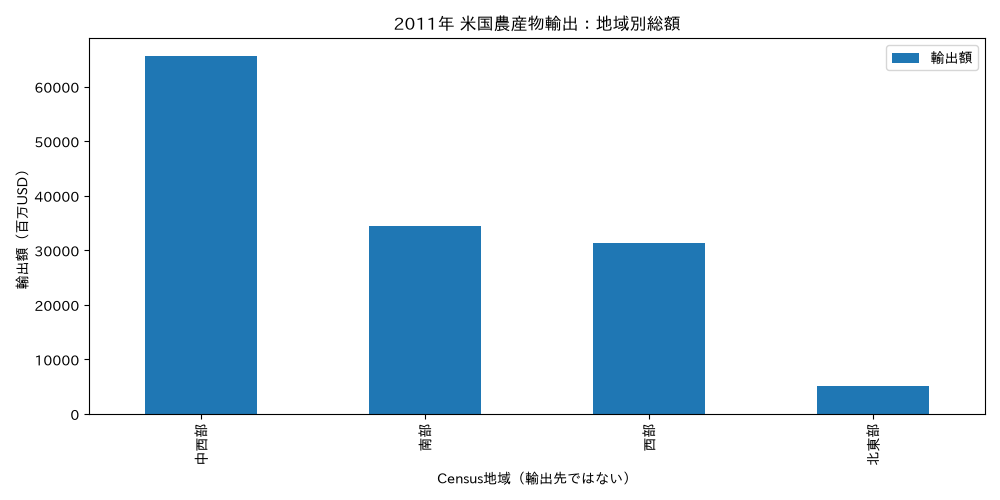

In [7]:
# 図1：地域別輸出額（比較しやすい共通ゼロ基準の棒グラフ）
import matplotlib.pyplot as plt
from matplotlib import font_manager, ft2font
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.autolayout'] = True
chart_records = {}
def show_chart(cell_id, png, meta, captured):
    font_path = font_manager.findfont(font_manager.FontProperties())
    font = ft2font.FT2Font(font_path)
    text = ''.join(str(meta[k]) for k in ['title','xlabel','ylabel','legend','tick_labels'])
    missing = sorted({ord(ch) for ch in text if not ch.isspace() and font.get_char_index(ord(ch)) == 0})
    warning_glyphs = [str(w.message) for w in captured if 'Glyph' in str(w.message)]
    meta.update({'missing_glyphs':missing,'glyph_warnings':warning_glyphs,'font':Path(font_path).name,
                 'image_sha256':hashlib.sha256(png).hexdigest(),'visual_review':'zero_baseline_or_0_100_color_range; labeled_denominator'})
    if missing or warning_glyphs:
        raise RuntimeError('図表に欠落グリフを検知')
    chart_records[cell_id] = meta
    (data_dir/(cell_id+'.png')).write_bytes(png)
    (data_dir/'chart-metadata.json').write_text(json.dumps(chart_records, ensure_ascii=False, indent=2), encoding='utf-8')
    output = visualization.build_image_output(png)
    display(output.data, raw=True)
    emit('図表情報_'+cell_id, meta)
with phase('地域図'):
    plot_df = region_totals.sort_values('輸出額_百万USD', ascending=False).reset_index().rename(columns={'region':'地域','輸出額_百万USD':'輸出額'})
    meta = {'title':'2011年 米国農産物輸出：地域別総額','xlabel':'Census地域（輸出先ではない）','ylabel':'輸出額（百万USD）','legend':'輸出額','tick_labels':list(plot_df['地域'])}
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        png = visualization.render_chart(plot_df, kind='bar', x='地域', y='輸出額', title=meta['title'], xlabel=meta['xlabel'], ylabel=meta['ylabel'])
    show_chart('chart-region', png, meta, captured)


図表情報_chart-commodity={"font": "ipaexg.ttf", "glyph_warnings": [], "image_sha256": "0ac342ee1a1478638d1a061ac9f518f76adcd086687af4954657371d7053ccc5", "legend": "輸出額", "missing_glyphs": [], "tick_labels": ["果物（合計）", "トウモロコシ", "小麦", "綿花", "豚肉", "野菜（合計）", "家禽肉", "牛肉", "乳製品"], "title": "2011年 掲載9品目の輸出額：親子列の重複を除外", "visual_review": "zero_baseline_or_0_100_color_range; labeled_denominator", "xlabel": "掲載品目（農産物全体の内訳ではない）", "ylabel": "輸出額（百万USD・品目単位は推定）"}


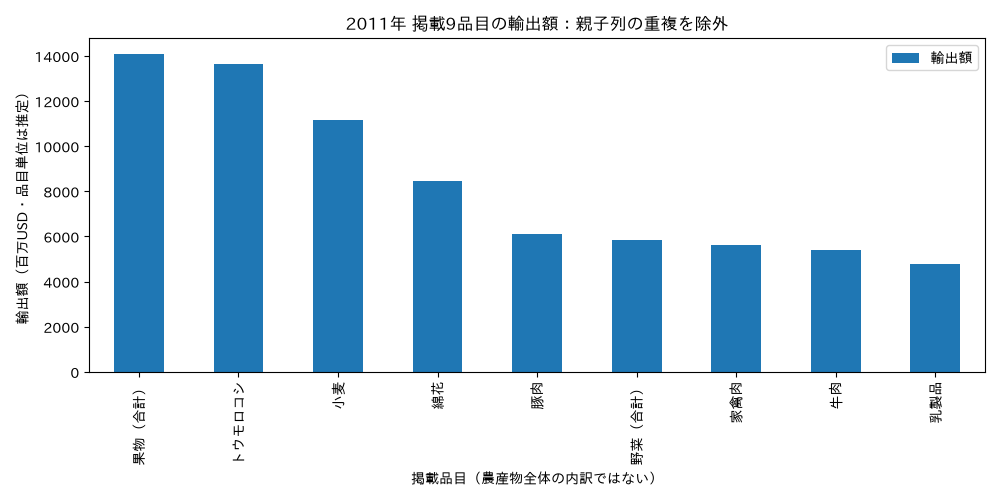

In [8]:
# 図2：掲載9品目の輸出額（全品目ではない）
with phase('品目図'):
    plot_df = commodity_totals.reset_index().rename(columns={'index':'品目','輸出額_百万USD':'輸出額'})
    meta = {'title':'2011年 掲載9品目の輸出額：親子列の重複を除外','xlabel':'掲載品目（農産物全体の内訳ではない）','ylabel':'輸出額（百万USD・品目単位は推定）','legend':'輸出額','tick_labels':list(plot_df['品目'])}
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        png = visualization.render_chart(plot_df, kind='bar', x='品目', y='輸出額', title=meta['title'], xlabel=meta['xlabel'], ylabel=meta['ylabel'])
    show_chart('chart-commodity', png, meta, captured)


図表情報_chart-heatmap={"font": "ipaexg.ttf", "glyph_warnings": [], "image_sha256": "263f1278329b4c83a5c6c48bc07b15b58b25b6c0c1721073d0957670b2ea7b64", "legend": "品目内地域構成比（%）", "missing_glyphs": [], "tick_labels": ["牛肉", "豚肉", "家禽肉", "乳製品", "果物（合計）", "野菜（合計）", "トウモロコシ", "小麦", "綿花", "北東部", "中西部", "南部", "西部"], "title": "2011年 各品目の輸出額を占める地域比率", "visual_review": "zero_baseline_or_0_100_color_range; labeled_denominator", "xlabel": "品目（各列の地域合計 = 100%）", "ylabel": "Census地域"}


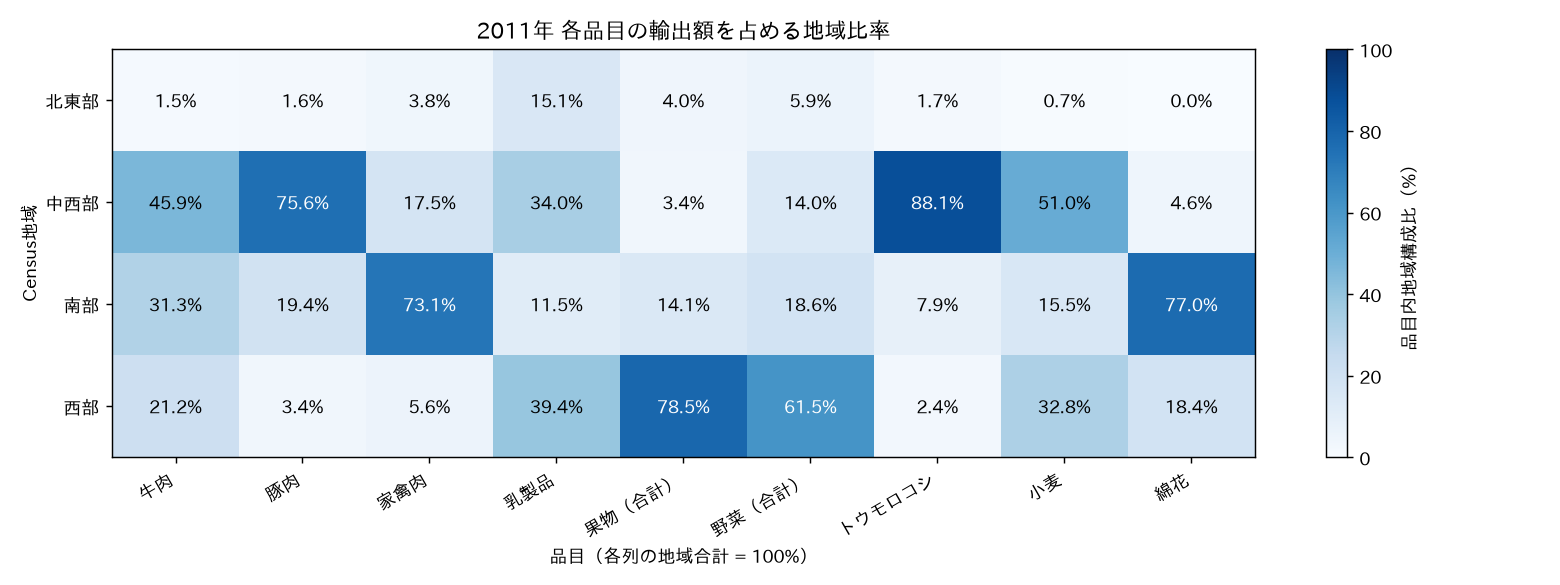

In [9]:
# 図3：品目内の地域構成比ヒートマップ（列ごとに100%）
with phase('品目地域図'):
    matrix = commodity_region_share.rename(columns=labels)
    meta = {'title':'2011年 各品目の輸出額を占める地域比率','xlabel':'品目（各列の地域合計 = 100%）','ylabel':'Census地域','legend':'品目内地域構成比（%）','tick_labels':list(matrix.columns)+list(matrix.index)}
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        fig, ax = plt.subplots(figsize=(12,4.5))
        im = ax.imshow(matrix.to_numpy(), vmin=0, vmax=100, cmap='Blues', aspect='auto')
        ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=30, ha='right')
        ax.set_yticks(range(len(matrix.index)), matrix.index)
        ax.set_title(meta['title']); ax.set_xlabel(meta['xlabel']); ax.set_ylabel(meta['ylabel'])
        for row in range(matrix.shape[0]):
            for col in range(matrix.shape[1]):
                val = matrix.iloc[row,col]
                ax.text(col,row,f'{val:.1f}%',ha='center',va='center',color='white' if val>55 else 'black')
        fig.colorbar(im, ax=ax, label=meta['legend'])
        fig.tight_layout()
        buffer = io.BytesIO(); fig.savefig(buffer,format='png',dpi=130); plt.close(fig)
        png = buffer.getvalue()
    show_chart('chart-heatmap', png, meta, captured)


**初回Insight：集計対象と単位。** Plotly公式例がこのCSVの総額列を2011年・百万USDと表示している。CSVの50州合計は136,444.45百万USD（1,364.4445億USD）。輸出先の国・地域や最新年を表すものではなく、暦年/会計年度と州への計上方法は当該CSVに直接結びつく資料では未確認。

```evidence
{"execution_count":6,"cited_value":"136444.45","claim_type":"descriptive"}
```

**初回Insight：地域の構成。** 金額を州から積み上げると中西部48.10%、南部25.21%、西部23.00%、北東部3.69%。中西部は約半分だが50%は超えない。Census地域別の金額構成であり、生産性・一人当たり輸出・因果効果ではない。

```evidence
{"execution_count":6,"cited_value":"48.09920081029313","claim_type":"descriptive"}
```

**初回Insight：掲載品目は全体ではない。** 親子重複を除いた掲載9品目は総額の55.06%のみ。果物14,089.50、トウモロコシ13,652.10、小麦11,141.20百万USDの順だが、未掲載44.94%の品目内容が不明で「全農産物で果物が首位」とは言えない。品目列の百万USD単位は総額列からの推定を含む。

```evidence
{"execution_count":6,"cited_value":"55.062921210793114","claim_type":"descriptive"}
```

**初回Insight：品目内の地域集中。** 果物の78.53%は西部、トウモロコシの88.08%は中西部、綿花の76.96%は南部。これは各品目内での地域比率であり、各地域内の構成比とは異なる。公式品目境界は未確認なので列名に即した記述に限る。

```evidence
{"execution_count":6,"cited_value":"78.52883352851414","claim_type":"descriptive"}
```

## 反復依頼履歴
### 反復1：原文
掲載9品目が総額の約55%にしかならない点を再検討してください。地域ごとの未掲載残差を示し、掲載品目だけを分母にした場合に地域構成の結論がどう変わるか比較してください。果物・野菜の親列と生鮮・加工の子列の差が丸め誤差の範囲か確認し、親列/子列の選択と表示丸めに対する感度分析を実施してください。未掲載部分に特定の品目名を推測で付けないでください。

選定理由：掲載9品目で説明されない金額が大きく、分母の混同が結論を変え得る。初回出力を再読して選定。

In [10]:
# 反復1：未掲載部分・分母・丸めの検討
with phase('反復1_集計対象感度'):
    residual_by_region = df.groupby('region')[['total exports','listed_total','unlisted_residual']].sum().reindex(region_order)
    residual_by_region['掲載率_pct'] = residual_by_region.listed_total / residual_by_region['total exports'] * 100
    residual_by_region['全品目総額での地域比_pct'] = residual_by_region['total exports']/total_musd*100
    residual_by_region['掲載9品目だけの地域比_pct'] = residual_by_region.listed_total/df.listed_total.sum()*100
    display(residual_by_region.round(6))
    def coverage_spec(aggregation, rounding):
        values = df.copy()
        if aggregation == 'children':
            values['total fruits'] = values[['fruits fresh','fruits proc']].sum(axis=1)
            values['total veggies'] = values[['veggies fresh','veggies proc']].sum(axis=1)
        if rounding != 'reported':
            sign = -1 if rounding=='lower' else 1
            for col in core:
                half_step = 0.05 if col in ['beef','pork','poultry','corn','wheat'] else (0.1 if aggregation=='children' and col in ['total fruits','total veggies'] else 0.005)
                values[col] = (values[col] + sign*half_step).clip(lower=0)
            values['total exports'] = values['total exports'] - sign*0.005
        return float(values[core].sum().sum()/values['total exports'].sum()*100)
    rounding_plan = sensitivity.SensitivityPlan(parameter_grid={'aggregation':['parent','children'],'rounding':['reported','lower','upper']},max_runs=6)
    rounding_report = sensitivity.run_sensitivity(rounding_plan,coverage_spec,stability_tolerance=0.001)
    iteration1_metrics = {'listed_coverage_min_pct':min(r.value for r in rounding_report.results),
                          'listed_coverage_max_pct':max(r.value for r in rounding_report.results),
                          'rounding_stable':rounding_report.stable,
                          'rounding_max_relative_deviation':rounding_report.max_relative_deviation,
                          'midwest_share_using_listed_only_pct':float(residual_by_region.loc['中西部','掲載9品目だけの地域比_pct']),
                          'fruit_max_parent_child_difference_musd':float(fruit_difference.abs().max()),
                          'veggie_max_parent_child_difference_musd':float(vegetable_difference.abs().max())}
    emit('ITERATION1_METRICS',iteration1_metrics)
    display(json.dumps(iteration1_metrics,ensure_ascii=False,sort_keys=True))
    emit('感度分析1全結果',asdict(rounding_report))
    print('選定理由: 約45%の未掲載部分があり、分母の選択は地域構成と品目順位の一般化に実質的影響。')
    print('残る限界: 丸めの上下は表示精度に基づく保守的境界で確率区間ではない。品目単位・分類定義は検証し切れていない。残差の内容は不明。')
    (data_dir/'iteration1-metrics.json').write_text(json.dumps(iteration1_metrics,ensure_ascii=False,indent=2),encoding='utf-8')
    (data_dir/'rounding-sensitivity.json').write_text(json.dumps(asdict(rounding_report),ensure_ascii=False,indent=2),encoding='utf-8')


ITERATION1_METRICS={"fruit_max_parent_child_difference_musd": 0.08999999999999986, "listed_coverage_max_pct": 55.079959426637416, "listed_coverage_min_pct": 55.0471912796906, "midwest_share_using_listed_only_pct": 38.743143578556186, "rounding_max_relative_deviation": 0.0003094317458944067, "rounding_stable": true, "veggie_max_parent_child_difference_musd": 0.09000000000014552}
感度分析1全結果={"baseline_value": 55.062921210793114, "max_relative_deviation": 0.0003094317458944067, "results": [{"specification": {"aggregation": "parent", "rounding": "reported"}, "value": 55.062921210793114}, {"specification": {"aggregation": "parent", "rounding": "lower"}, "value": 55.05386431279484}, {"specification": {"aggregation": "parent", "rounding": "upper"}, "value": 55.072916254410245}, {"specification": {"aggregation": "children", "rounding": "reported"}, "value": 55.063001829682335}, {"specification": {"aggregation": "children", "rounding": "lower"}, "value": 55.0471912796906}, {"specification": {"agg

,total exports,listed_total,unlisted_residual,掲載率_pct,全品目総額での地域比_pct,掲載9品目だけの地域比_pct
region,,,,,,
北東部,5030.60,2333.46,2697.14,46.385322,3.686922,3.105884
中西部,65628.69,29107.84,36520.85,44.352310,48.099201,38.743144
南部,34401.81,19944.06,14457.75,57.973868,25.213052,26.545961
西部,31383.35,23744.94,7638.41,75.660948,23.000826,31.605012


'{"fruit_max_parent_child_difference_musd": 0.08999999999999986, "listed_coverage_max_pct": 55.079959426637416, "listed_coverage_min_pct": 55.0471912796906, "midwest_share_using_listed_only_pct": 38.743143578556186, "rounding_max_relative_deviation": 0.0003094317458944067, "rounding_stable": true, "veggie_max_parent_child_difference_musd": 0.09000000000014552}'

**反復1の結果：分母の変更は結論を変える。** 掲載9品目だけを分母にすると中西部38.74%、西部31.61%、南部26.55%、北東部3.11%となり、全品目総額の南部>西部が逆転する。地域別掲載率は中西部44.35%、西部75.66%と異なるため、掲載品目から全農産物構成を代用できない。残差は品目不明の差額であり、特定品目とは命名しない。根拠：iteration1の地域別表。

```evidence
{"execution_count":10,"cited_value":"38.743143578556186","claim_type":"descriptive"}
```

**反復1の感度結果：丸め・親子集約には安定。** 果物・野菜の親子差は各州最大約0.09百万USDで、表示丸めの上限0.105百万USD以下。親列/子列と丸め上下の6仕様で掲載率55.0472–55.0800%、stable=True、max_relative_deviation=0.0003094317458944067（相対約0.03094%）。丸めは約45%の未掲載部分を説明できない。残る限界：品目単位と境界を同じものとする意味上の前提までは検証できない。

```evidence
{"execution_count":10,"cited_value":"0.0003094317458944067","claim_type":"descriptive"}
```

## 反復依頼履歴（続き）
### 反復2：原文
果物は西部、トウモロコシは中西部、綿花は南部に集中するという結果が、それぞれの大規模輸出州だけに依存していないか調べてください。各品目の最大州と地域内での寄与率を示し、50州の各1州を除く感度分析で地域の首位と過半数が維持されるか確認してください。州の除外は母集団を変える診断であり、不確実性の信頼区間や外れ値除去の正当化と混同しないでください。

選定理由：初回地域比の大きさとCaliforniaの州総額首位を再読し、地域全体に広く分布するか、一州寄与かを区別する。

In [11]:
# 反復2：州集中と全50州のleave-one-out感度
with phase('反復2_大規模州依存'):
    focus = {'total fruits':'西部','corn':'中西部','cotton':'南部'}
    influence_rows = []
    influence_reports = {}
    loo_plan = sensitivity.SensitivityPlan(parameter_grid={'excluded_code':['none']+sorted(df.code.tolist())},max_runs=51)
    for commodity, focal_region in focus.items():
        top = df.loc[df[commodity].idxmax()]
        def region_share_spec(excluded_code):
            subset = df if excluded_code=='none' else df.loc[df.code.ne(excluded_code)]
            return float(subset.loc[subset.region.eq(focal_region),commodity].sum()/subset[commodity].sum()*100)
        report = sensitivity.run_sensitivity(loo_plan,region_share_spec,stability_tolerance=0.1)
        winners = []
        for result in report.results:
            excluded = result.specification['excluded_code']
            subset = df if excluded=='none' else df.loc[df.code.ne(excluded)]
            grouped = subset.groupby('region')[commodity].sum()
            winners.append(grouped.idxmax())
        top_removed = next(r.value for r in report.results if r.specification['excluded_code']==top.code)
        influence_rows.append({'品目':labels[commodity], '地域':focal_region, '最大州':top.state, '州コード':top.code,
                               '最大州の品目全国比_pct':float(top[commodity]/df[commodity].sum()*100),
                               '最大州の所属地域品目比_pct':float(top[commodity]/df.loc[df.region.eq(top.region),commodity].sum()*100),
                               '基本地域比_pct':report.baseline_value,'最大州除外の地域比_pct':top_removed,
                               '全仕様の首位地域維持':all(w==focal_region for w in winners),
                               '全仕様で過半数':all(r.value>50 for r in report.results),
                               'stable_相対10pct許容':report.stable,'max_relative_deviation':report.max_relative_deviation})
        influence_reports[commodity] = asdict(report)
    influence_table = pd.DataFrame(influence_rows)
    display(influence_table)
    fruit_row = influence_rows[0]
    iteration2_metrics = {'fruit_west_without_ca_pct':fruit_row['最大州除外の地域比_pct'],
                          'fruit_west_max_relative_deviation':fruit_row['max_relative_deviation'],
                          'corn_midwest_without_largest_pct':influence_rows[1]['最大州除外の地域比_pct'],
                          'cotton_south_without_largest_pct':influence_rows[2]['最大州除外の地域比_pct'],
                          'all_three_keep_regional_leader':all(r['全仕様の首位地域維持'] for r in influence_rows)}
    emit('ITERATION2_METRICS',iteration2_metrics)
    display(json.dumps(iteration2_metrics,ensure_ascii=False,sort_keys=True))
    print('選定理由: 初回の地域集中という表現が一州の規模に依存し得る。地域合計と州内分布の違いを確認する。')
    print('残る限界: 除外は記述対象を変える診断で統計的CIではない。実際の50州値から大規模州を除外すべきという結論ではない。地域首位・過半数・量的安定性を別々に判定する。')
    (data_dir/'iteration2-metrics.json').write_text(json.dumps(iteration2_metrics,ensure_ascii=False,indent=2),encoding='utf-8')
    (data_dir/'state-influence-sensitivity.json').write_text(json.dumps(influence_reports,ensure_ascii=False,indent=2),encoding='utf-8')
    influence_table.to_csv(data_dir/'state-influence.csv',index=False)


ITERATION2_METRICS={"all_three_keep_regional_leader": true, "corn_midwest_without_largest_pct": 85.36723519415949, "cotton_south_without_largest_pct": 68.31842195440025, "fruit_west_max_relative_deviation": 0.44622474131679646, "fruit_west_without_ca_pct": 43.48732510134315}
選定理由: 初回の地域集中という表現が一州の規模に依存し得る。地域合計と州内分布の違いを確認する。
残る限界: 除外は記述対象を変える診断で統計的CIではない。実際の50州値から大規模州を除外すべきという結論ではない。地域首位・過半数・量的安定性を別々に判定する。


,品目,地域,最大州,州コード,最大州の品目全国比_pct,最大州の所属地域品目比_pct,基本地域比_pct,最大州除外の地域比_pct,全仕様の首位地域維持,全仕様で過半数,stable_相対10pct許容,max_relative_deviation
0,果物（合計）,西部,California,CA,62.006459,78.960117,78.528834,43.487325,True,False,False,0.446225
1,トウモロコシ,中西部,Iowa,IA,18.530482,21.038538,88.078757,85.367235,True,True,True,0.030785
2,綿花,南部,Texas,TX,27.270161,35.435104,76.958039,68.318422,True,True,False,0.143887


'{"all_three_keep_regional_leader": true, "corn_midwest_without_largest_pct": 85.36723519415949, "cotton_south_without_largest_pct": 68.31842195440025, "fruit_west_max_relative_deviation": 0.44622474131679646, "fruit_west_without_ca_pct": 43.48732510134315}'

**反復2の結果：集中の強さと州依存を区別。** Californiaは果物列合計の62.01%、西部内の78.96%を占める。California除外で西部43.49%となり過半数ではなくなる。Iowa除外後のトウモロコシ中西部比率は85.37%、Texas除外後の綿花南部比率は68.32%。全50州の1州除外で3品目とも元の地域首位は維持するが、「各地域全般に均等に集中」とは言えない。根拠：iteration2の州寄与表と51仕様×3品目。

```evidence
{"execution_count":11,"cited_value":"43.48732510134315","claim_type":"descriptive"}
```

**反復2の感度結果：量的安定性は品目による。** 相対10%を許容幅とした51仕様では、果物stable=False・max_relative_deviation=0.44622474131679646、トウモロコシstable=True・約0.030785、綿花stable=False・約0.143887。首位地域が変わらなくても比率の量的安定性は保証されない。限界：1州除外は母集団変更診断であり、確率的な信頼区間ではない。

```evidence
{"execution_count":11,"cited_value":"0.44622474131679646","claim_type":"descriptive"}
```

## 反復依頼履歴（続き）
### 反復3：原文
残っている定義上の不確実性を点検してください。果物・野菜の生鮮と加工の列が、州ごとに独立の構成情報を含むのか、それとも表示丸めの範囲で共通比率による分割と整合するのかを調べてください。Census公式の地域一覧と全50州の割当ても機械的に照合してください。計上年の種類・州への帰属方法・正式な品目分類は、確認できた出典と未確認点を区別し、推定を事実に格上げしないでください。

選定理由：品目の加工区分定義が未確認というmanifestの留保を再読し、数値列の独立情報と公式地域の一致を追加検査する。

In [12]:
# 反復3：生鮮・加工の情報量と公式地域照合
with phase('反復3_意味的定義'):
    split_checks = []
    for family in ['fruits','veggies']:
        fresh, proc = df[family+' fresh'], df[family+' proc']
        positive = fresh>0.05
        low = ((proc[positive]-0.05).clip(lower=0)/(fresh[positive]+0.05))
        high = (proc[positive]+0.05)/(fresh[positive]-0.05)
        intersection_low = float(low.max()); intersection_high = float(high.min())
        feasible = intersection_low <= intersection_high
        fresh_regions = df.groupby('region')[family+' fresh'].sum()/fresh.sum()*100
        proc_regions = df.groupby('region')[family+' proc'].sum()/proc.sum()*100
        split_checks.append({'family':family,'positive_states':int(positive.sum()),
                             'common_ratio_lower':intersection_low,'common_ratio_upper':intersection_high,
                             'constant_split_compatible_with_rounding':feasible,
                             'fresh_proc_max_regional_share_gap_pp':float((fresh_regions-proc_regions).abs().max())})
    census_raw = (data_dir/'census-source.txt').read_text(encoding='utf-8')
    official_name_to_region = {}
    region_header = list(re.finditer(r'REGION\s+(?:I|[1-4]):\s*(NORTHEAST|MIDWEST|SOUTH|WEST)', census_raw))
    translation = {'NORTHEAST':'北東部','MIDWEST':'中西部','SOUTH':'南部','WEST':'西部'}
    for i, match in enumerate(region_header):
        block = census_raw[match.end():region_header[i+1].start() if i+1<len(region_header) else len(census_raw)]
        for state in df.state:
            if re.search(r'(?<![A-Za-z])'+re.escape(state)+r'\s*\(',block):
                official_name_to_region[state] = translation[match.group(1)]
    assert len(official_name_to_region)==50, '公式地域表との州名照合に欠落'
    region_mismatches = df.loc[df.region.ne(df.state.map(official_name_to_region)), ['code','state','region']]
    assert region_mismatches.empty, '地域割当てが公式一覧と不一致'
    iteration3_metrics = {'fruit_fresh_proc_max_region_gap_pp':split_checks[0]['fresh_proc_max_regional_share_gap_pp'],
                          'veggie_fresh_proc_max_region_gap_pp':split_checks[1]['fresh_proc_max_regional_share_gap_pp'],
                          'census_state_matches':len(official_name_to_region),
                          'census_region_mismatches':len(region_mismatches)}
    display(pd.DataFrame(split_checks))
    emit('ITERATION3_METRICS',iteration3_metrics)
    display(json.dumps(iteration3_metrics,ensure_ascii=False,sort_keys=True))
    print('出典判定: Plotly公式例は2011年・総額の百万USDを確認。Census公式資料は地域分類を確認。USDA資料には生産・現金収入に基づく州配賦と積出/移動起点系列の異なる定義があるが、このCSVへの対応は確定できない。')
    print('選定理由: 生鮮/加工の正式定義は未確認で、親子列の数値整合性だけでは独立の測定情報とは限らない。地域誤割当ては品目地域の結論に影響する。')
    print('残る限界: 共通比率と整合しても生成手法を確定したことにはならない。時点の種類・公式品目境界・計上方法の未確認は公開CSVだけでは解消できない。')
    (data_dir/'iteration3-metrics.json').write_text(json.dumps(iteration3_metrics,ensure_ascii=False,indent=2),encoding='utf-8')
    (data_dir/'fresh-processed-semantic-check.json').write_text(json.dumps(split_checks,ensure_ascii=False,indent=2),encoding='utf-8')


ITERATION3_METRICS={"census_region_mismatches": 0, "census_state_matches": 50, "fruit_fresh_proc_max_region_gap_pp": 0.001964110980192224, "veggie_fresh_proc_max_region_gap_pp": 0.006527795995179275}
出典判定: Plotly公式例は2011年・総額の百万USDを確認。Census公式資料は地域分類を確認。USDA資料には生産・現金収入に基づく州配賦と積出/移動起点系列の異なる定義があるが、このCSVへの対応は確定できない。
選定理由: 生鮮/加工の正式定義は未確認で、親子列の数値整合性だけでは独立の測定情報とは限らない。地域誤割当ては品目地域の結論に影響する。
残る限界: 共通比率と整合しても生成手法を確定したことにはならない。時点の種類・公式品目境界・計上方法の未確認は公開CSVだけでは解消できない。


,family,positive_states,common_ratio_lower,common_ratio_upper,constant_split_compatible_with_rounding,fresh_proc_max_regional_share_gap_pp
0,fruits,49,2.129251,2.129363,True,0.001964
1,veggies,48,1.622720,1.623047,True,0.006528


'{"census_region_mismatches": 0, "census_state_matches": 50, "fruit_fresh_proc_max_region_gap_pp": 0.001964110980192224, "veggie_fresh_proc_max_region_gap_pp": 0.006527795995179275}'

In [13]:
# Jupytermind改善候補の限定再現（データ分析結果とは別）
with phase('モジュール機能確認'):
    diagnostic_manifest = data_definition.build_manifest(source={},dataset_scope={},variables={'amount':{'unit':data_definition.FieldValue('百万USD','inferred','テスト用推定')}})
    inferred_omission = len(diagnostic_manifest.unresolved_fields())==0
    chart_cell = next(c for c in nbformat.read(handle.notebook_path,as_version=4).cells if c.id=='chart-region')
    missing_meta_cell = nbformat.from_dict(json.loads(nbformat.writes(nbformat.v4.new_notebook(cells=[chart_cell])))).cells[0]
    missing_meta_cell.metadata.pop('chart',None)
    toy_notebook = nbformat.v4.new_notebook(cells=[missing_meta_cell])
    missing_metadata_findings = notebook_audit.audit_visual_outputs(toy_notebook,(0,))
    diagnostics_log = {'unresolved_fields_omits_inferred':inferred_omission,
                       'inferred_only_unresolved_count':len(diagnostic_manifest.unresolved_fields()),
                       'chart_without_metadata_visual_findings':[asdict(f) for f in missing_metadata_findings],
                       'layout_clip_before_fix_artifacts':['chart-region-before-layout.png','chart-commodity-before-layout.png'],
                       'layout_workaround':'figure.autolayout=True',
                       'external_issue_separation':'SDK page_size不対応と%20保存ファイル名はKaggle呼出側。stdio注入制約・実行中Notebook自己書換え競合はMCP統合経路。Copilot/ベンチマークランナーの障害は本実験では観測なし。'}
    emit('JUPYTERMIND_DIAGNOSTICS',diagnostics_log)
    display(json.dumps(diagnostics_log,ensure_ascii=False,sort_keys=True))
    (data_dir/'jupytermind-improvement-diagnostics.json').write_text(json.dumps(diagnostics_log,ensure_ascii=False,indent=2),encoding='utf-8')


JUPYTERMIND_DIAGNOSTICS={"chart_without_metadata_visual_findings": [], "external_issue_separation": "SDK page_size不対応と%20保存ファイル名はKaggle呼出側。stdio注入制約・実行中Notebook自己書換え競合はMCP統合経路。Copilot/ベンチマークランナーの障害は本実験では観測なし。", "inferred_only_unresolved_count": 0, "layout_clip_before_fix_artifacts": ["chart-region-before-layout.png", "chart-commodity-before-layout.png"], "layout_workaround": "figure.autolayout=True", "unresolved_fields_omits_inferred": true}


'{"chart_without_metadata_visual_findings": [], "external_issue_separation": "SDK page_size不対応と%20保存ファイル名はKaggle呼出側。stdio注入制約・実行中Notebook自己書換え競合はMCP統合経路。Copilot/ベンチマークランナーの障害は本実験では観測なし。", "inferred_only_unresolved_count": 0, "layout_clip_before_fix_artifacts": ["chart-region-before-layout.png", "chart-commodity-before-layout.png"], "layout_workaround": "figure.autolayout=True", "unresolved_fields_omits_inferred": true}'

**反復3の結果：加工区分に独立の地域情報が乏しい。** 果物49州・野菜48州の正の生鮮額について、加工/生鮮の共通比率は表示丸めと整合し、地域比率の最大差は果物0.001964110980192224ポイント、野菜0.006527795995179275ポイントしかない。独立した観測による州別加工度の違いをこのCSVから推論しない。共通比率の分割が可能という数値診断であり、実際の生成方法を確定したものではない。公式Census表との50州割当ては不一致0件。根拠：iteration3の区間・地域照合。

```evidence
{"execution_count":12,"cited_value":"0.001964110980192224","claim_type":"descriptive"}
```

## 反復の終了判断と残る限界
3回の原文依頼を実行した。反復1は全体/部分品目の分母と丸め、反復2は大規模州依存、反復3は加工区分の情報量と地域割当てを確認し、結論に実質的に必要な区別を追加した。同じCSVで新しい統計を追加しても、暦年/会計年度・2011年の州帰属方法・正式品目境界・未掲載44.94%の内容・Kaggle版との完全同一性は解消できないため、追加反復を止める。最大3回の上限にも到達した。結論は2011年の当該CSVの記述に限定し、現在の輸出構成や輸出先の国・地域、因果効果に一般化しない。

分析前提check_manifestの未解決警告は2件：品目列と総額列の共通通貨単位、残差を未掲載部分と解釈する前提。両者を仮定のまま保持する。残差は特定の作物・加工品の額とみなさない。独立した参照データによる数値検証は未実施。ファイル同定の再現性と意味定義の確認度を別々に報告する。


## 使用したJupytermindモジュール
直接import・呼び出したもののみを列挙。制御Notebookでの呼出しも、その場所を明記する。間接importは使用済みに含めない。

| モジュール | 直接呼び出した関数・クラス・メソッド | 使用目的・場所 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 安定した指定保存先とデータ保存先、制御Notebookから構造・根拠・監査記録を直列書込み |
| ai_data_scientist.language_router | detect_language | 日本語指示の判定（setup） |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, get_run_status, mark_completed, mark_failed, wait_for_quiescence | run_id=v020-exp-28、分析実行と制御Notebook書込みの追跡・終了・静止確認 |
| ai_data_scientist.ingestion | SourceSpec, ingest | 取得CSVを上限付き読込み（acquisition） |
| ai_data_scientist.cleaning | clean_dataset | 重複除去の影響確認：50→50行、削除0（quality） |
| ai_data_scientist.eda | explore | 型・欠損・記述統計・カテゴリ分布（quality） |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 単位・観測対象・計上方法の確信度。inferredも手動併記（definitions, module-diagnostics） |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 記述的スコープと結論重要前提の警告（quality） |
| ai_data_scientist.data_quality | detect_anomalies | 非負・非欠損・州一意・許容集合の意味的検査（quality） |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 親子・丸め6仕様、1州除外51仕様×3品目（iteration1/2） |
| ai_data_scientist.visualization | render_chart, build_image_output | 地域・品目棒グラフと画像MIME出力（chart-*）。ヒートマップ描画自体はMatplotlib |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 実行済みMIME出力から無丸めの値を抽出しInsightを記録。制御Notebookで呼出し |
| ai_data_scientist.notebook_audit | audit_notebook, audit_visual_outputs | visual_audit=Trueの実行・根拠・画像監査、メタデータ欠落診断 |

不適用：mcp_gateway.run_and_recordは既存stdio MCP接続のPython注入不可のため直接Jupyter MCPツールで代替し、使用済みに数えない。独立した対応参照データがないためdataset_validation.compare_datasets / data_quality.validate_anomaliesは使用しない。相関や外れ値z-scoreは品目構成・50州の悉皆的記述という問いに不要。因果推論・予測・ML・確率的標本CIも対象外。


## Jupytermind改善候補

### 候補1：定義不確実性の列挙範囲（仕様/Skill説明の不一致）
- 再現条件：module-diagnosticsでunitのstatus=inferredだけを持つbuild_manifestを作りunresolved_fields()を呼ぶ。
- 期待：Skill手順12の意図に沿ってinferred/unknown双方を列挙するか、unknown_onlyであることをAPI名・文書で明示する。
- 実際：inferred_only_unresolved_count=0。関数docstring自体はunknownだけと明記しており、実装単独のバグとは断定しない。
- 影響：推定単位を未解決一覧だけで点検すると見落とす。
- 回避策：definitionsで全FieldValueを走査し、unknown/inferred双方を「推定も含めた注意一覧」に出す。
- 関係セル/ログ：definitions、module-diagnostics、data/jupytermind-improvement-diagnostics.json、data/data-definition-manifest.json。

### 候補2：図表ラベルの下端切れ（可視化のレイアウト不足）
- 再現条件：render_chartで10×5インチ、9品目の長い日本語tickラベルを持つbarを描画。初回はfigure.autolayoutが無効。
- 期待：タイトル・全tickラベル・軸名が画像内に収まる。
- 実際：chart-commodityの初回PNGで長い品目名下端とxlabelが切れた。グリフ欠落は0でも可読性に問題。
- 影響：品目の識別・分母の説明が読めない。
- 回避策：chart-regionでfigure.autolayout=Trueを設定し、棒グラフを再描画。修正後PNGを目視し全軸名と品目名を確認。
- 関係セル/ログ：chart-region、chart-commodity、data/chart-commodity-before-layout.png（SHA-256: 64811addc59f57bd95248baafca9b23b64b270c570e08f5906a1a2605680fcd1）、data/chart-region-before-layout.png、data/chart-metadata.json。

### 候補3：図表メタデータ欠落が監査されない（監査の検出範囲不足）
- 再現条件：module-diagnosticsで実画像出力のあるchart-regionコピーからmetadata.chartを取り除きaudit_visual_outputsを呼ぶ。
- 期待：missing_glyphsの検査情報、title/xlabel/ylabel/legendメタデータが欠けていることを報告する。
- 実際：chart_without_metadata_visual_findings=[]。メタデータが完全欠落した場合はlabel検査がスキップされる。軸切れも画像密度では検出できない。
- 影響：visual_audit=Trueの合格だけではラベル・グリフ検査の実施を保証できない。
- 回避策：各図の実タイトル/軸/凡例・font cmapによる欠落グリフ・警告ログを保存して、制御Notebookからセルmetadata.chartを付与。最終監査前にメタデータ存在を別assertで確認し、PNGを目視する。
- 関係セル/ログ：module-diagnostics、chart-*、final-audit、data/jupytermind-improvement-diagnostics.json、data/chart-metadata.json。

### 外部問題との切り分け
Kaggle SDKのdataset_list(page_size=...)不対応（TypeError）と空白を%20化する保存ファイル名は呼出側/SDKの問題で修正済み。最終的なフォールバック理由は通信障害ではなく、検索・取得したCSVの観測対象/スキーマ不一致（provenance.json参照）。MCPの実行中Notebook自己書換えとの競合は統合経路の制約であり、今回別Notebook書込みで回避し、本実験内では新たな自己書換え競合を再現していない。Copilot CLIやベンチマークランナー固有の障害は観測なし。以上は改善候補であり、ライブラリコードの変更やGitHub Issueの登録は本依頼では行っていない。


## 再実行と監査
初回指標をfirst-run-metrics.jsonに保存。以下のコードを含め、カーネル再起動後にすべてのコードセルを上からJupyter MCPで実行する。Insightの根拠実行番号は制御Notebookから実際の再実行セルに更新し、最終セルは読取り専用の監査と終了状態記録だけを行う。

In [14]:
# 再実行照合：初回の主要数値とファイル同一性
with phase('再現性照合'):
    first_run = json.loads((data_dir/'first-run-metrics.json').read_text(encoding='utf-8'))
    current = {'main-metrics.json':metrics,'iteration1-metrics.json':iteration1_metrics,
               'iteration2-metrics.json':iteration2_metrics,'iteration3-metrics.json':iteration3_metrics}
    numeric_checks = []
    for artifact, initial in first_run.items():
        assert set(initial)==set(current[artifact])
        for key,value in initial.items():
            observed = current[artifact][key]
            if isinstance(value,(float,int)) and not isinstance(value,bool):
                passed = bool(np.isclose(value,observed,rtol=1e-12,atol=1e-12))
                numeric_checks.append({'artifact':artifact,'key':key,'first':value,'rerun':observed,'passed':passed})
            else:
                passed = value==observed
            assert passed, '初回との結果不一致: '+artifact+'/'+key
    assert hashlib.sha256(selected_path.read_bytes()).hexdigest()==provenance['first_acquisition']['sha256']
    repro_result = {'numeric_check_count':len(numeric_checks),'all_passed':all(c['passed'] for c in numeric_checks),
                    'data_sha256_unchanged':True,'tolerance':'rtol=atol=1e-12','scope':'主要指標のみ。出典HTML/取得時刻の一致を要求しない'}
    emit('REPRODUCIBILITY',repro_result)
    display(json.dumps(repro_result,ensure_ascii=False,sort_keys=True))
    (data_dir/'reexecution-comparison.json').write_text(json.dumps({'summary':repro_result,'checks':numeric_checks},ensure_ascii=False,indent=2),encoding='utf-8')
    (data_dir/'execution-phase-log.json').write_text(json.dumps(phase_log,ensure_ascii=False,indent=2),encoding='utf-8')


REPRODUCIBILITY={"all_passed": true, "data_sha256_unchanged": true, "numeric_check_count": 25, "scope": "主要指標のみ。出典HTML/取得時刻の一致を要求しない", "tolerance": "rtol=atol=1e-12"}


'{"all_passed": true, "data_sha256_unchanged": true, "numeric_check_count": 25, "scope": "主要指標のみ。出典HTML/取得時刻の一致を要求しない", "tolerance": "rtol=atol=1e-12"}'

In [15]:
# 最終監査（読み取り専用、構造・根拠・図表メタデータは制御Notebookで確定済み）
with phase('最終Notebook監査'):
    persisted = nbformat.read(handle.notebook_path,as_version=4)
    for chart_id in ['chart-region','chart-commodity','chart-heatmap']:
        cell = next(c for c in persisted.cells if c.id==chart_id)
        chart = cell.metadata.get('chart',{})
        assert all(key in chart for key in ['missing_glyphs','title','xlabel','ylabel','legend']), '図表メタデータ欠落'
        assert not chart['missing_glyphs']
        assert chart['image_sha256']==chart_records[chart_id]['image_sha256'], '図表メタデータが古い'
    audit = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    emit('notebook_audit',{'ok':audit.ok,**asdict(audit)})
    assert audit.ok, 'Notebook監査に未解決エラー'
    (data_dir/'notebook-audit-self.json').write_text(json.dumps({'ok':audit.ok,**asdict(audit)},ensure_ascii=False,indent=2),encoding='utf-8')
lc.mark_completed(run_id)
final_status = lc.wait_for_quiescence(run_id,timeout_s=5)
assert final_status.state=='completed' and final_status.active_cell_executions==0 and final_status.pending_notebook_writes==0 and final_status.locks_held==0
emit('FINAL_LIFECYCLE',asdict(final_status))
(data_dir/'lifecycle-final.json').write_text(json.dumps(asdict(final_status),ensure_ascii=False,indent=2),encoding='utf-8')
(data_dir/'execution-phase-log.json').write_text(json.dumps(phase_log,ensure_ascii=False,indent=2),encoding='utf-8')


notebook_audit={"chart_cell_indices": [8, 9, 10], "code_cell_count": 15, "error_cell_indices": [], "executed_code_cell_count": 14, "findings": [{"cell_index": 32, "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.", "severity": "warning"}], "insight_cell_count": 9, "nbformat_valid": true, "ok": true, "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-28-ag-exports/notebooks/kaggle-v020-kaggle-exp-28-ag-exports.ipynb", "unexecuted_cell_indices": [], "visual_findings": []}
FINAL_LIFECYCLE={"active_cell_executions": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-28-ag-exports/notebooks/kaggle-v020-kaggle-exp-28-ag-exports.ipynb", "pending_notebook_writes": 0, "reason": null, "run_id": "v020-exp-28", "state": "completed"}


3064

## 最終実行証跡

カーネル再起動後、全15コードセルを上から実行（execution_count=1–15）。初回との主要数値25項目がrtol=atol=1e-12で一致し、再取得CSVのSHA-256も初回と一致。9個のInsightを実際の再実行出力へ同期。図表3枚の日本語グリフ・凡例・軸ラベル・画像密度を監査し、棒グラフの下端切れも回避後に目視確認。最終セル内の自己監査は実行中セル除外の警告を1件含むが、保存完了後に別の制御Notebookから再監査した下記結果は15/15実行済み・未実行0・エラー0・findings=[]・visual_findings=[]。

```json
{
  "audited_at_utc": "2026-10-01T21:03:44.470700+00:00",
  "ok": true,
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-28-ag-exports/notebooks/kaggle-v020-kaggle-exp-28-ag-exports.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 15,
  "executed_code_cell_count": 15,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    8,
    9,
    10
  ],
  "insight_cell_count": 9,
  "findings": [],
  "visual_findings": [],
  "reexecution": {
    "kernel_restarted": true,
    "code_execution_counts": [
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15
    ],
    "numeric_check_count": 25,
    "all_passed": true,
    "data_sha256_unchanged": true,
    "tolerance": "rtol=atol=1e-12",
    "scope": "主要指標のみ。出典HTML/取得時刻の一致を要求しない"
  },
  "lifecycle": {
    "run_id": "v020-exp-28",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-28-ag-exports/notebooks/kaggle-v020-kaggle-exp-28-ag-exports.ipynb",
    "reason": null
  }
}
```

実行フェーズログ：data/execution-phase-log.json。最終書込みフェーズログ：data/control-write-phase-log.json。来歴：data/provenance.json。ライフサイクル：run_id=v020-exp-28、completed、実行中0・書込み待ち0・保持ロック0。分析前提の意味的留保2件と改善候補3件は監査合格によって解消したものではない。